In [103]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math

In [136]:
# read the data (flux tower and in-situ NO2data, LAI data, inferred NO2 concentration data, etc.)
# read the flux tower data together with the in-situ nitrogen measurement data
Loobos_meteo = pd.read_csv('../Data/VeluweInSitu/Loobos_Flux_30min_23-25.csv' , sep=',')
# Delete NA data represented by -9999.999 in the original dataset
Loobos_meteo = Loobos_meteo.replace(-9999.999, np.nan)
# print out the header
print(Loobos_meteo.head())

             Timestamp        H        L       LE  P_1_1_1   RH_1_1_1  \
0  2023-01-01 00:30:00 -28.6111  8561.43  64.4297      NaN  58.566778   
1  2023-01-01 01:00:00 -45.5390  3664.26  55.2674      NaN  58.634111   
2  2023-01-01 01:30:00 -23.2093  8399.95  65.6980      NaN  60.356222   
3  2023-01-01 02:00:00 -45.6610  4076.76  63.9316      NaN  60.026889   
4  2023-01-01 02:30:00 -16.7186  9879.25  58.2393      NaN  59.655111   

   SW_IN_1_1_1  SW_OUT_1_1_1   TA_1_1_1    WD_2_1_1  WS_2_1_1       u*  
0    -4.587133     -3.092433  15.279111  225.966667  6.466778  1.40866  
1    -4.258978     -3.206900  15.314444  222.300000  6.960444  1.23955  
2    -6.914678     -2.860533  14.947778  222.111111  6.989778  1.30553  
3    -4.324711     -3.141467  14.767444  220.477778  6.904444  1.28562  
4    -4.296511     -3.140433  14.672889  221.411111  6.093000  1.23539  


In [137]:
# Delete negative and larger than 10 m/s u* values, as they are likely to be erroneous and can significantly affect the analysis of NO2 dry deposition velocity and its drivers.
Loobos_meteo = Loobos_meteo[(Loobos_meteo['u*'] >= 0) & (Loobos_meteo['u*'] <= 10)]
# Ensure daytime column exists before applying the deposition function
Loobos_meteo['daytime'] = pd.to_datetime(Loobos_meteo['Timestamp'] , format='%Y-%m-%d %H:%M:%S')  # Timestamp is in YYYY-MM-DD HH:MM:SS format

In [138]:
# Calculate the deposition velocity (Vd) using micro-meteorological data
# Calculation of the NO2 dry deposition velocity, based on an assumed NO2 dry deposition stomatal uptake that is 2/3 that of O3.
# This calculation uses the Loobos observed micrometeorology and a prescribed LAI but the latter can still be replaced with a 3-D LAI field (time,lat,long) to consider the temporal and spatial variability in LAI.

# Constants
Sc = 1.1   # Schmidt number for NO2
Pr = 0.71  # Prandtl number for air
Rc = 1e5
g_s0 = 0.01
z = 10.0

# --- Meteorology functions ---

def calculate_vpd(T, RH):
    RH = RH / 100.0  # convert %
    e_s = 0.6108 * math.exp((17.27 * T) / (T + 237.3))
    e_a = RH * e_s
    return e_s - e_a

# Pre-compute VPD, Qmax and VPD_max from the full dataset
Loobos_meteo['VPD'] = Loobos_meteo.apply(
    lambda row: calculate_vpd(row['TA_1_1_1'], row['RH_1_1_1']), axis=1
)

Qmax   = Loobos_meteo['SW_IN_1_1_1'].max()
VPDmax = Loobos_meteo['VPD'].max()

# --- Resistance functions ---

def aerodynamic_resistance(u_star, z):
    k = 0.41
    return math.log(z / 0.1) / (k * u_star)

def boundary_layer_resistance(u_star, Sc, Pr):
    k = 0.41
    return (2 / (k * u_star)) * (Sc / Pr)**(2/3)

def stomatal_resistance(g_s, LAI):
    return 1 / (g_s * LAI)

def calculate_stomatal_conductance(Q, VPD, g_s0):
    gs = g_s0 * (Q / Qmax) * max(0.0, (VPDmax - VPD) / VPDmax)
    return max(gs, 1e-6)  # prevent zero or negative stomatal conductance

# --- Main deposition function ---

def wesely_dry_deposition_velocity(u_star, Q, VPD, LAI):

    g_s = calculate_stomatal_conductance(Q, VPD, g_s0)

    Ra = aerodynamic_resistance(u_star, z)
    Rb = boundary_layer_resistance(u_star, Sc, Pr)
    Rs = stomatal_resistance(g_s, LAI)

    # NO2 (2/3 uptake of O3 → stomatal resistance scaled by 1.5)
    Rsurf = 1 / (1 / (1.5 * Rs) + 1 / Rc)
    VdNO2 = 1 / (Ra + Rb + Rsurf)

    return VdNO2,g_s

# --- Apply to dataframe ---

def calculate_deposition_velocity_for_row(row):

    Q     = row['SW_IN_1_1_1']
    VPD   = row['VPD']
    u_star = row['u*']
    LAI   = 2.26  # or replace with dynamic value later

    VdNO2, g_s = wesely_dry_deposition_velocity(u_star, Q, VPD, LAI)

    return pd.Series({
        'VdNO2 (cm s-1)': 100 * VdNO2,
        'g_s (m s-1)': g_s
    })

# Apply
Loobos_meteo[['VdNO2 (cm s-1)', 'g_s (m s-1)']] = Loobos_meteo.apply(
    calculate_deposition_velocity_for_row, axis=1
)
print(Loobos_meteo)

                 Timestamp         H          L         LE   P_1_1_1  \
0      2023-01-01 00:30:00 -28.61110  8561.4300  64.429700       NaN   
1      2023-01-01 01:00:00 -45.53900  3664.2600  55.267400       NaN   
2      2023-01-01 01:30:00 -23.20930  8399.9500  65.698000       NaN   
3      2023-01-01 02:00:00 -45.66100  4076.7600  63.931600       NaN   
4      2023-01-01 02:30:00 -16.71860  9879.2500  58.239300       NaN   
...                    ...       ...        ...        ...       ...   
52555  2025-12-30 22:00:00 -22.25200    28.9323  -1.137540  0.000000   
52556  2025-12-30 22:30:00 -11.22170    14.4861  -0.871331  0.000000   
52557  2025-12-30 23:00:00 -16.84500    26.5020  -1.246770  0.000567   
52558  2025-12-30 23:30:00 -20.03160    24.8437  -2.133380  0.000633   
52559  2025-12-31 00:00:00  -5.93714    16.9606   0.030577  0.001000   

        RH_1_1_1  SW_IN_1_1_1  SW_OUT_1_1_1   TA_1_1_1    WD_2_1_1  WS_2_1_1  \
0      58.566778    -4.587133     -3.092433  15.279111 

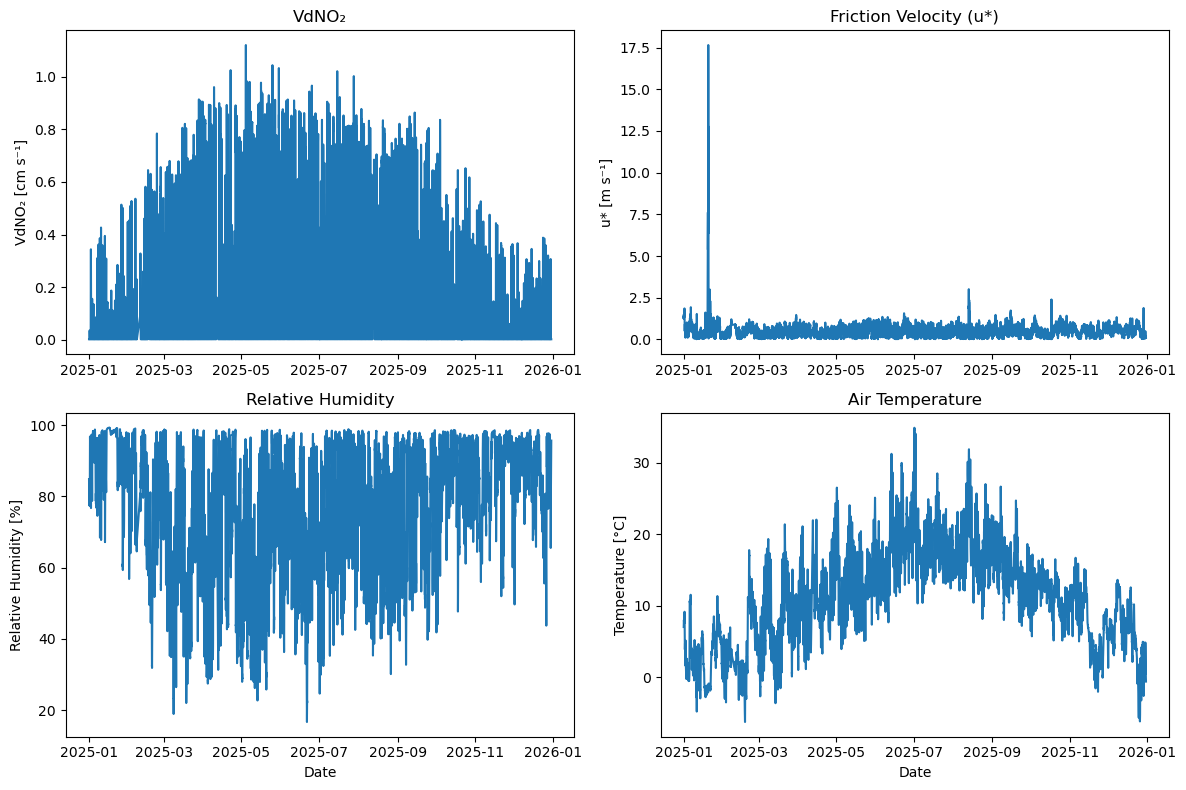

In [42]:
# Creating a plot of the calculated NO2 dry deposition velocity and its physical/biological drivers
# Create a figure and set of subplots (2 rows, 2 columns)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# NO2 deposition velocity
axs[0, 0].plot(Loobos_meteo['daytime'], Loobos_meteo['VdNO2 (cm s-1)'])
axs[0, 0].set_title('VdNO₂')
axs[0, 0].set_ylabel('VdNO₂ [cm s⁻¹]')

# Friction velocity
axs[0, 1].plot(Loobos_meteo['daytime'], Loobos_meteo['u*'])
axs[0, 1].set_title('Friction Velocity (u*)')
axs[0, 1].set_ylabel('u* [m s⁻¹]')

# Relative humidity
axs[1, 0].plot(Loobos_meteo['daytime'], Loobos_meteo['RH_1_1_1'])
axs[1, 0].set_title('Relative Humidity')
axs[1, 0].set_xlabel('Date')
axs[1, 0].set_ylabel('Relative Humidity [%]')

# Air temperature
axs[1, 1].plot(Loobos_meteo['daytime'], Loobos_meteo['TA_1_1_1'])
axs[1, 1].set_title('Air Temperature')
axs[1, 1].set_xlabel('Date')
axs[1, 1].set_ylabel('Temperature [°C]')

plt.tight_layout()
plt.show()

In [47]:
# print the vdno2 for june
print(Loobos_meteo[Loobos_meteo['daytime'].dt.month == 6][['daytime', 'VdNO2 (cm s-1)']])

                  daytime  VdNO2 (cm s-1)
42335 2025-06-01 00:00:00        0.001169
42336 2025-06-01 00:30:00        0.001169
42337 2025-06-01 01:00:00        0.001168
42338 2025-06-01 01:30:00        0.001168
42339 2025-06-01 02:00:00        0.001169
...                   ...             ...
43770 2025-06-30 21:30:00        0.001169
43771 2025-06-30 22:00:00        0.001169
43772 2025-06-30 22:30:00        0.001169
43773 2025-06-30 23:00:00        0.001169
43774 2025-06-30 23:30:00        0.001169

[1433 rows x 2 columns]


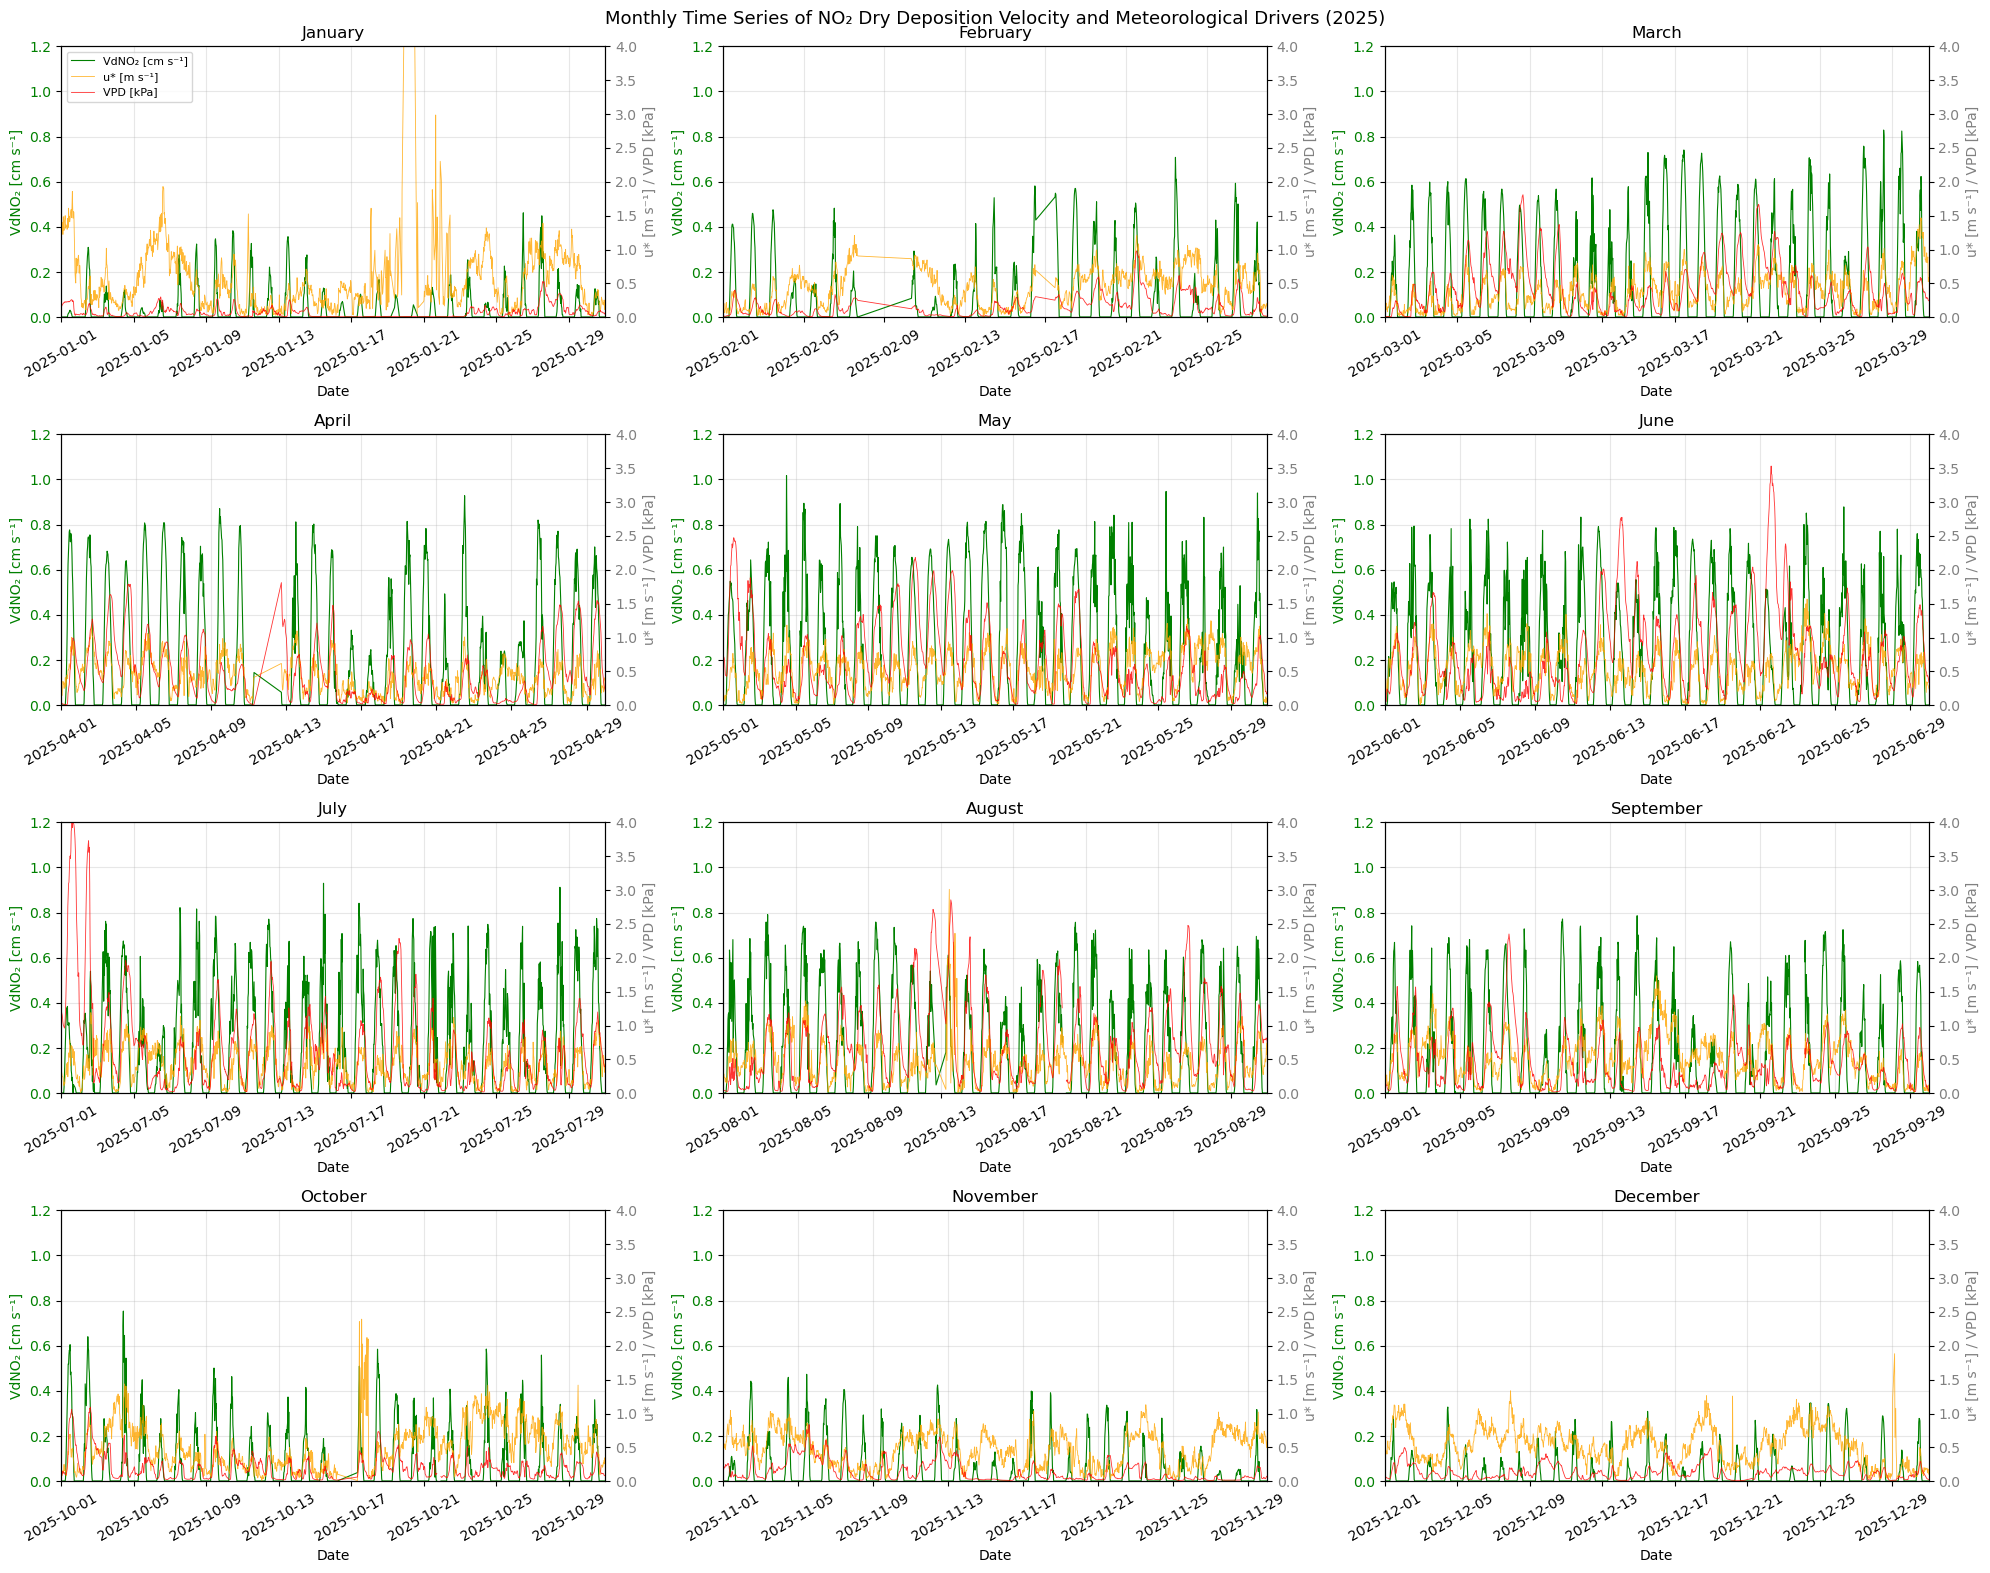

In [51]:
# make a function to plot the monthly time-series of NO2 dry deposition velocity and its drivers (u* and VPD) for the growing season (May to September)
import calendar
# Monthly time-series of NO2 dry deposition velocity with meteorological drivers
months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

fig, axs = plt.subplots(4, 3, figsize=(20, 16))
axs = axs.flatten()

for i, month in enumerate(months):
    df_month = Loobos_meteo[Loobos_meteo['daytime'].dt.month == month]

    ax_left = axs[i]
    ax_right = ax_left.twinx()

    # --- Left axis: VdNO2 ---
    l1, = ax_left.plot(df_month['daytime'], df_month['VdNO2 (cm s-1)'],
                       color='green', linewidth=0.8, label='VdNO₂ [cm s⁻¹]')

    # --- Right axis: u* ---
    l2, = ax_right.plot(df_month['daytime'], df_month['u*'],
                        color='orange', linewidth=0.6, alpha=0.8, label='u* [m s⁻¹]')

    # --- Right axis: VPD ---
    l3, = ax_right.plot(df_month['daytime'], df_month['VPD'],
                        color='red', linewidth=0.6, alpha=0.8, label='VPD [kPa]')

    # --- Axis labels ---
    ax_left.set_title(month_names[month])
    ax_left.set_xlabel('Date')
    ax_left.set_ylabel('VdNO₂ [cm s⁻¹]', color='green')
    ax_right.set_ylabel('u* [m s⁻¹] / VPD [kPa]', color='gray')

    ax_left.tick_params(axis='x', rotation=30)
    ax_left.tick_params(axis='y', labelcolor='green')
    ax_right.tick_params(axis='y', labelcolor='gray')

    ax_left.set_ylim(0, 1.2)
    ax_right.set_ylim(0, 4) # same scale for all months to facilitate comparison, adjust as needed based on data range

    first_day = pd.Timestamp(2025, month, 1)
    last_day  = pd.Timestamp(2025, month, calendar.monthrange(2025, month)[1])
    ax_left.set_xlim(first_day, last_day)

    ax_left.grid(alpha=0.3)

    # --- Legend (first subplot only) ---
    if i == 0:
        lines = [l1, l2, l3]
        labels = [l.get_label() for l in lines]
        ax_left.legend(lines, labels, fontsize=8, loc='upper left')


plt.suptitle('Monthly Time Series of NO₂ Dry Deposition Velocity and Meteorological Drivers (2025)',
             fontsize=13)
# also want to avoid suptitle and subplots overlap
plt.subplots_adjust(top=0.93)
plt.tight_layout()
plt.show()

In [52]:
# Read the monthly mean LAI value from the CSV file
lai_monthly_avg = pd.read_csv('../Data/Sentinel2/Monthly_Avg_LAI_2025.csv')
print(lai_monthly_avg)

    Month  Average_LAI
0       1     1.901072
1       2     1.814807
2       3     1.695553
3       4     1.750757
4       5     2.260861
5       6     2.527382
6       7     2.765724
7       8     2.849220
8       9     2.907809
9      10     2.941250
10     11     2.756312
11     12     2.539803


In [53]:
# Calculate the deposition velocity (Vd) using micro-meteorological data
# Calculation of the NO2 dry deposition velocity, based on an assumed NO2 dry deposition stomatal uptake that is 2/3 that of O3.
# This calculation uses the Loobos observed micrometeorology and monthly LAI values derived from Sentinel-2.

# Constants
Sc = 1.1   # Schmidt number for NO2
Pr = 0.71  # Prandtl number for air
Rc = 1e5
g_s0 = 0.01
z = 10.0


# --- Meteorology functions ---

def calculate_vpd(T, RH):
    RH = RH / 100.0  # convert %
    e_s = 0.6108 * math.exp((17.27 * T) / (T + 237.3))
    e_a = RH * e_s
    return e_s - e_a

# Pre-compute VPD, Qmax and VPDmax from the full dataset
Loobos_meteo['VPD'] = Loobos_meteo.apply(
    lambda row: calculate_vpd(row['TA_1_1_1'], row['RH_1_1_1']), axis=1
)

Qmax   = Loobos_meteo['SW_IN_1_1_1'].max()
VPDmax = Loobos_meteo['VPD'].max()

# Build a month -> LAI lookup dictionary from the monthly LAI dataframe
lai_lookup = lai_monthly_avg.set_index('Month')['Average_LAI'].to_dict()

# --- Resistance functions ---

def aerodynamic_resistance(u_star, z):
    k = 0.41
    u_star = max(u_star, 1e-6)
    return math.log(z / 0.1) / (k * u_star)

def boundary_layer_resistance(u_star, Sc, Pr):
    k = 0.41
    return (2 / (k * u_star)) * (Sc / Pr)**(2/3)

def stomatal_resistance(g_s, LAI):
    return 1 / (g_s * LAI)

def calculate_stomatal_conductance(Q, VPD, g_s0):
    gs = g_s0 * (Q / Qmax) * max(0.0, (VPDmax - VPD) / VPDmax)
    return max(gs, 1e-6)  # prevent zero or negative stomatal conductance

# --- Main deposition function ---

def wesely_dry_deposition_velocity(u_star, Q, VPD, LAI):

    g_s = calculate_stomatal_conductance(Q, VPD, g_s0)

    Ra = aerodynamic_resistance(u_star, z)
    Rb = boundary_layer_resistance(u_star, Sc, Pr)
    Rs = stomatal_resistance(g_s, LAI)

    # NO2 (2/3 uptake of O3 → stomatal resistance scaled by 1.5)
    Rsurf = 1 / (1 / (1.5 * Rs) + 1 / Rc)
    VdNO2 = 1 / (Ra + Rb + Rsurf)

    return VdNO2

# --- Apply to dataframe ---

def calculate_deposition_velocity_for_row(row):

    Q      = row['SW_IN_1_1_1']
    VPD    = row['VPD']
    u_star = row['u*']
    month  = row['daytime'].month
    LAI    = lai_lookup[month]  # monthly LAI from Sentinel-2

    VdNO2 = wesely_dry_deposition_velocity(u_star, Q, VPD, LAI)

    return pd.Series({
        'VdNO2_ChangedLAI (cm s-1)': 100 * VdNO2
        })

# Apply
Loobos_meteo[['VdNO2_ChangedLAI (cm s-1)']] = Loobos_meteo.apply(
    calculate_deposition_velocity_for_row, axis=1
)
print(Loobos_meteo)

                 Timestamp         H           L        LE   P_1_1_1  \
35087  2025-01-01 00:00:00  14.10050 -13351.6000  1.389910  0.000000   
35088  2025-01-01 00:30:00  35.17560  -5946.7100  9.177450  0.000000   
35089  2025-01-01 01:00:00  23.77330 -10188.8000  5.720520  0.000000   
35090  2025-01-01 01:30:00  39.60200  -5878.7600  7.032530  0.000000   
35091  2025-01-01 02:00:00   6.91749 -23110.9000  9.420390  0.000000   
...                    ...       ...         ...       ...       ...   
52555  2025-12-30 22:00:00 -22.25200     28.9323 -1.137540  0.000000   
52556  2025-12-30 22:30:00 -11.22170     14.4861 -0.871331  0.000000   
52557  2025-12-30 23:00:00 -16.84500     26.5020 -1.246770  0.000567   
52558  2025-12-30 23:30:00 -20.03160     24.8437 -2.133380  0.000633   
52559  2025-12-31 00:00:00  -5.93714     16.9606  0.030577  0.001000   

        RH_1_1_1  SW_IN_1_1_1  SW_OUT_1_1_1  TA_1_1_1    WD_2_1_1  WS_2_1_1  \
35087  84.885556    -2.255211     -1.952022  7.021278  2

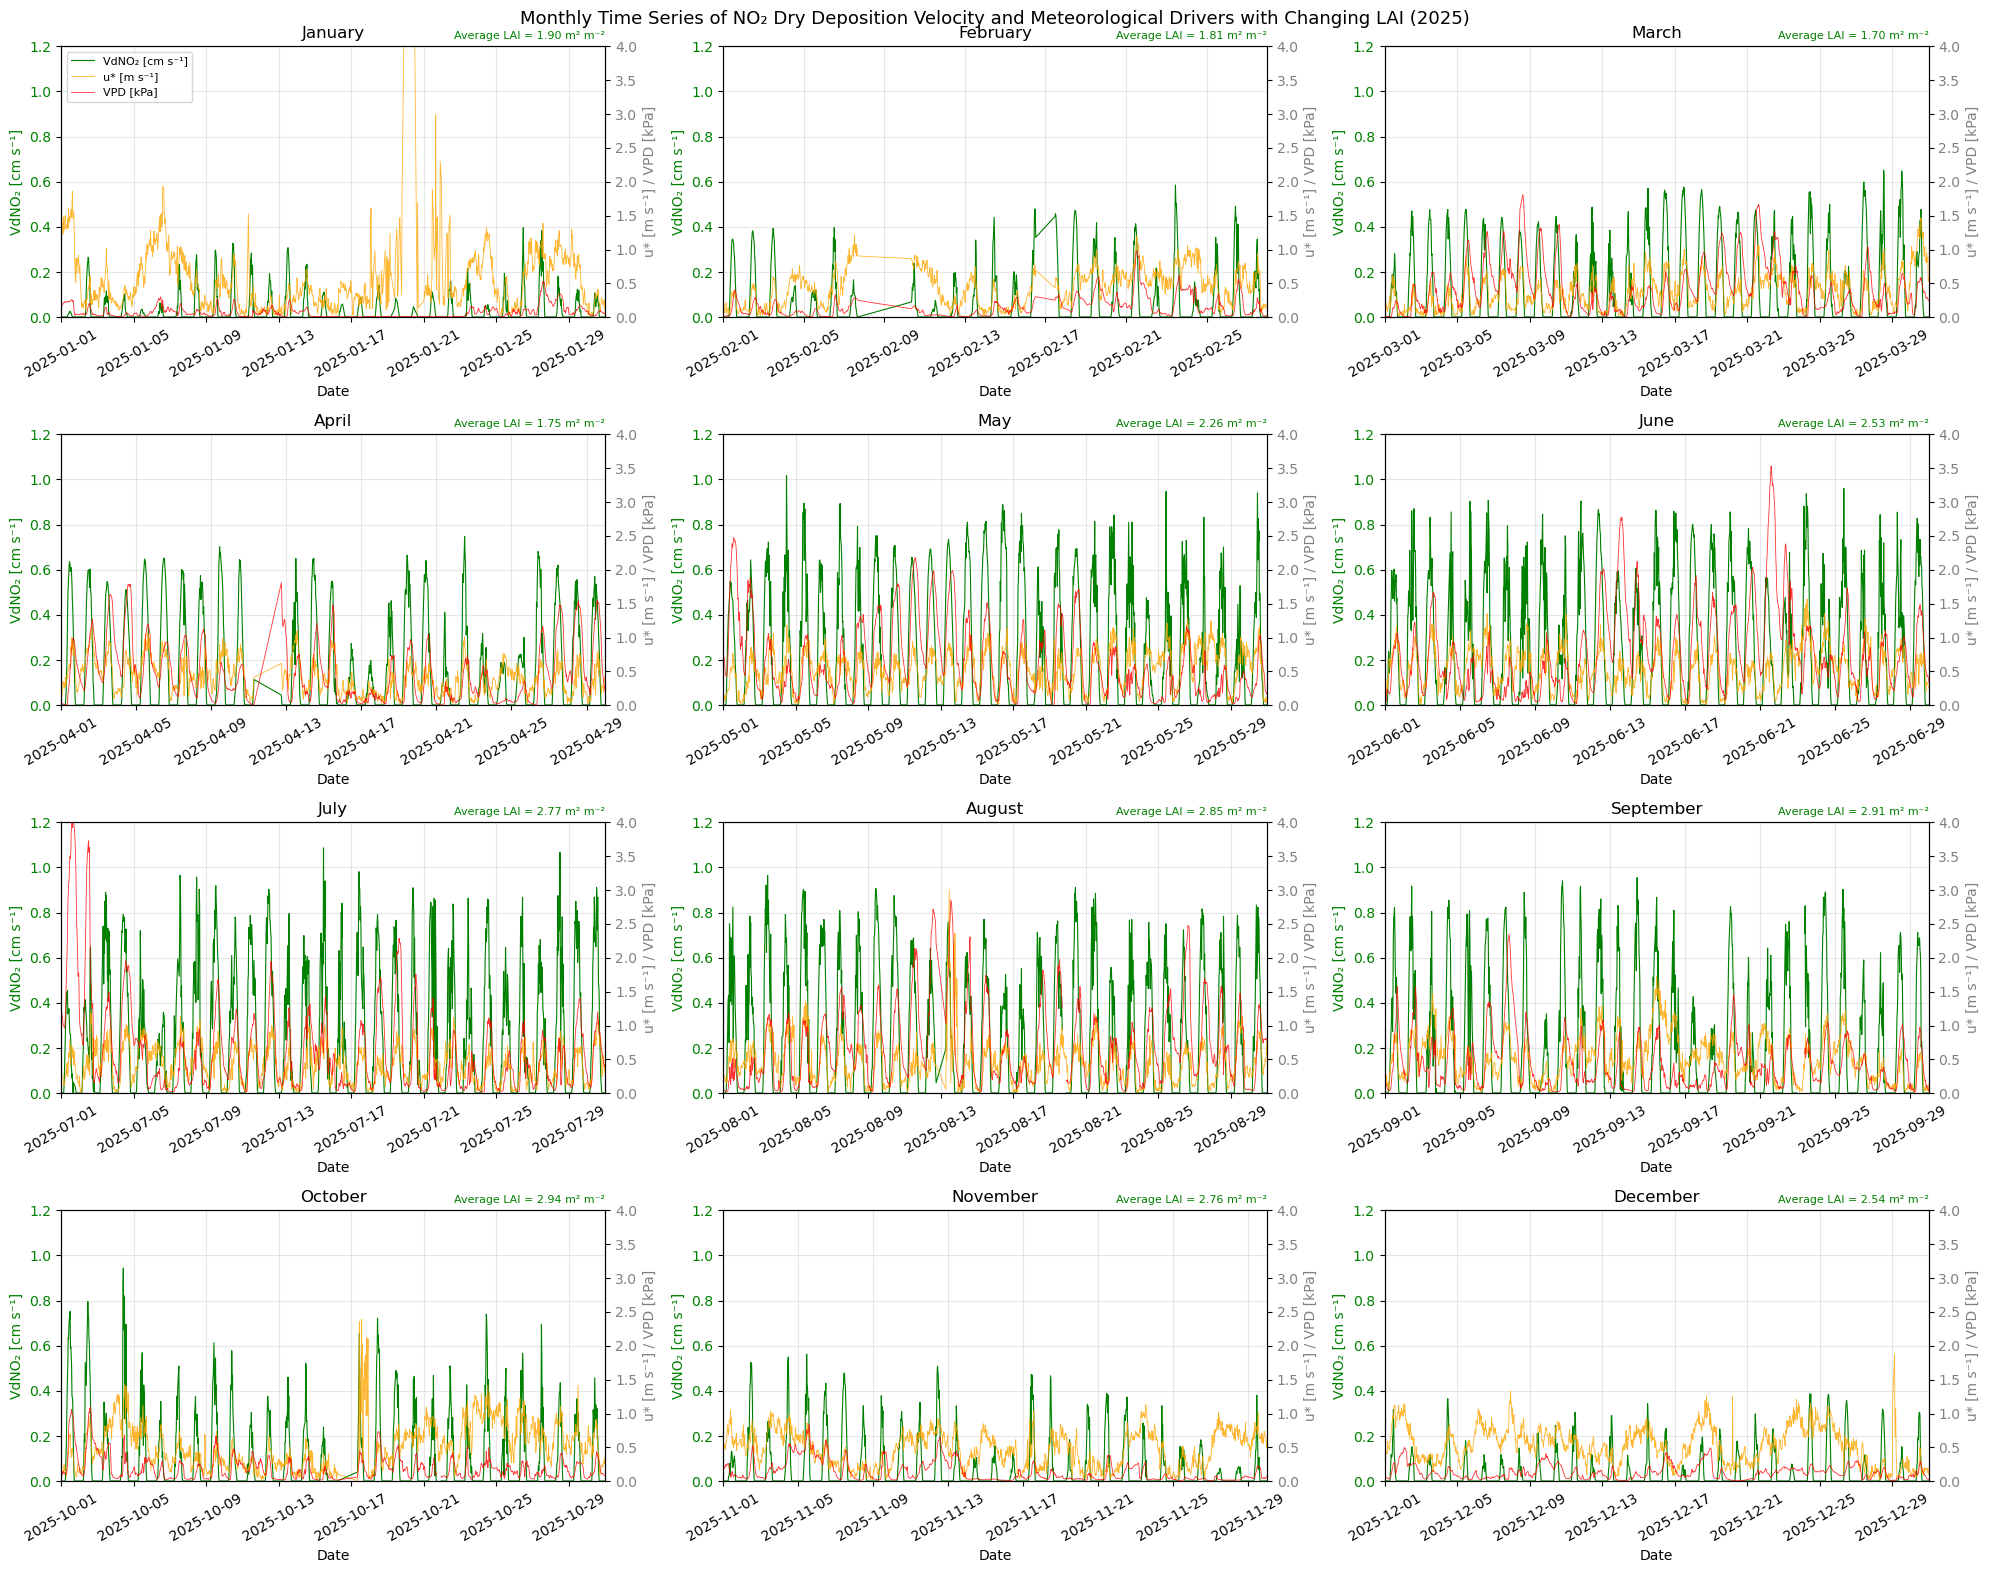

In [55]:
# Monthly time-series of NO2 dry deposition velocity with meteorological drivers
months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}


fig, axs = plt.subplots(4, 3, figsize=(20, 16))
axs = axs.flatten()

for i, month in enumerate(months):
    df_month = Loobos_meteo[Loobos_meteo['daytime'].dt.month == month]

    ax_left = axs[i]
    ax_right = ax_left.twinx()

    # --- Left axis: VdNO2 ---
    l1, = ax_left.plot(df_month['daytime'], df_month['VdNO2_ChangedLAI (cm s-1)'],
                       color='green', linewidth=0.8, label='VdNO₂ [cm s⁻¹]')

    # --- Right axis: u* ---
    l2, = ax_right.plot(df_month['daytime'], df_month['u*'],
                        color='orange', linewidth=0.6, alpha=0.8, label='u* [m s⁻¹]')

    # --- Right axis: VPD ---
    l3, = ax_right.plot(df_month['daytime'], df_month['VPD'],
                        color='red', linewidth=0.6, alpha=0.8, label='VPD [kPa]')

    # --- Axis labels ---
    ax_left.set_title(month_names[month])
    ax_left.set_xlabel('Date')
    ax_left.set_ylabel('VdNO₂ [cm s⁻¹]', color='green')
    ax_right.set_ylabel('u* [m s⁻¹] / VPD [kPa]', color='gray')

    ax_left.set_ylim(0, 1.2)
    ax_right.set_ylim(0, 4) # same scale for all months to facilitate comparison, adjust as needed based on data range

    ax_left.tick_params(axis='x', rotation=30)
    ax_left.tick_params(axis='y', labelcolor='green')
    ax_right.tick_params(axis='y', labelcolor='gray')

    first_day = pd.Timestamp(2025, month, 1)
    last_day  = pd.Timestamp(2025, month, calendar.monthrange(2025, month)[1])
    ax_left.set_xlim(first_day, last_day)

    ax_left.grid(alpha=0.3)

    # --- Legend (first subplot only) ---
    if i == 0:
        lines = [l1, l2, l3]
        labels = [l.get_label() for l in lines]
        ax_left.legend(lines, labels, fontsize=8, loc='upper left')

    # --- LAI annotation in upper right corner ---
    LAI_value = lai_lookup[month]
    ax_left.annotate(f'Average LAI = {LAI_value:.2f} m² m⁻²',
                     xy=(1.0, 1.02), xycoords='axes fraction',
                     ha='right', va='bottom', fontsize=8,
                     color='green')



plt.suptitle('Monthly Time Series of NO₂ Dry Deposition Velocity and Meteorological Drivers with Changing LAI (2025)',
             fontsize=13)
# also want to avoid suptitle and subplots overlap
plt.subplots_adjust(top=0.93)
plt.tight_layout()
plt.show()

In [60]:
# read in-situ NO2 concentration data
NO2_in_situ = pd.read_csv('../Data/VeluweInSitu/NO2&meteodata.csv', sep='\s+', skiprows=3)
# select relevant columns and filter for 2025
NO2_in_situ['daytime'] = pd.to_datetime(NO2_in_situ['Time']+' '+NO2_in_situ['Timestamp'], format='%Y-%m-%d %H:%M:%S')
NO2_in_situ_2025 = NO2_in_situ[NO2_in_situ['daytime'].dt.year == 2025]
print(NO2_in_situ_2025[['daytime', 'NO2_LGR_30m']])

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/d3/t7s8gmfn0kx2gvj756s_p17h0000gn/T/ipykernel_56821/102224821.py:2: SyntaxWarning: invalid escape sequence '\s'
  NO2_in_situ = pd.read_csv('../Data/VeluweInSitu/NO2&meteodata.csv', sep='\s+', skiprows=3)


                     daytime  NO2_LGR_30m
1800     2025-05-01 00:00:00   -9999.9990
3600     2025-05-01 00:30:00   -9999.9990
5400     2025-05-01 01:00:00       7.7791
7200     2025-05-01 01:30:00       7.6750
9000     2025-05-01 02:00:00       6.9508
...                      ...          ...
13212000 2025-09-30 21:30:00   -9999.9990
13213800 2025-09-30 22:00:00   -9999.9990
13215600 2025-09-30 22:30:00   -9999.9990
13217400 2025-09-30 23:00:00   -9999.9990
13219200 2025-09-30 23:30:00   -9999.9990

[7344 rows x 2 columns]


In [ ]:
# merge it with the calculated VdNO2 data based on the datetime
merged_data = pd.merge(Loobos_meteo, NO2_in_situ_2025[['daytime', 'NO2_LGR_30m']], on='daytime', how='inner')
print(merged_data[['daytime', 'VdNO2 (cm s-1)','VdNO2_ChangedLAI (cm s-1)', 'NO2_LGR_30m']])

                 daytime  VdNO2 (cm s-1)  VdNO2_ChangedLAI (cm s-1)  \
0    2025-05-01 00:00:00        0.001149                   0.001149   
1    2025-05-01 00:30:00        0.001145                   0.001146   
2    2025-05-01 01:00:00        0.001149                   0.001149   
3    2025-05-01 01:30:00        0.001148                   0.001148   
4    2025-05-01 02:00:00        0.001147                   0.001147   
...                  ...             ...                        ...   
7280 2025-09-30 21:30:00        0.001145                   0.001187   
7281 2025-09-30 22:00:00        0.001146                   0.001189   
7282 2025-09-30 22:30:00        0.001145                   0.001188   
7283 2025-09-30 23:00:00        0.001143                   0.001185   
7284 2025-09-30 23:30:00        0.001148                   0.001191   

      NO2_LGR_30m  
0      -9999.9990  
1      -9999.9990  
2          7.7791  
3          7.6750  
4          6.9508  
...           ...  
7280   

In [65]:
# delete negative and zero NO2 concentration values, as they are likely to be erroneous and can significantly affect the calculation of deposition fluxes.
merged_data = merged_data[merged_data['NO2_LGR_30m'] > 0]

In [66]:
# Use NO2 measurement data as the surface layer concentration
M_N = 14.0067  # molar mass of nitrogen
M_NO2 = 46.0055  # molar mass of NO2
merged_data['NO2_ugN_m3'] = merged_data['NO2_LGR_30m'] * (M_N / M_NO2) # convert NO2 concentration from µg/m³ to µgN/m³
merged_data['Fdep_NO2_stableLAI'] = merged_data['NO2_ugN_m3']*merged_data['VdNO2 (cm s-1)']/100  # convert cm/s to m/s for flux calculation'] 
merged_data['Fdep_NO2_ChangedLAI'] = merged_data['NO2_ugN_m3']*merged_data['VdNO2_ChangedLAI (cm s-1)']/100  # convert cm/s to m/s for flux calculation']

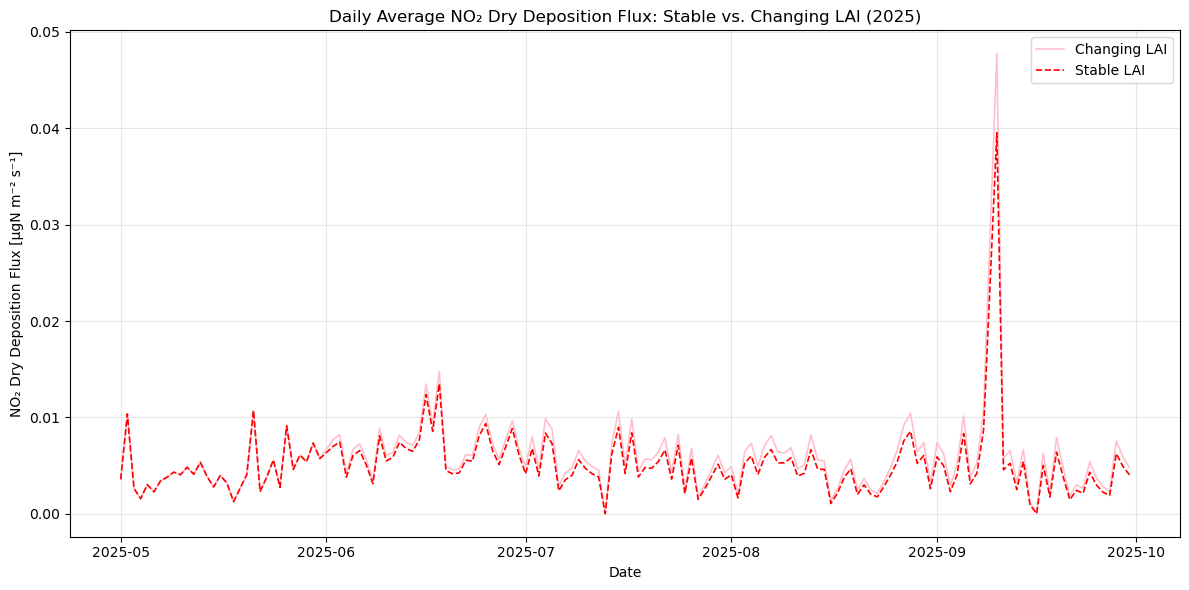

In [67]:
# Calculate daily average deposition flux for stable and changing LAI
Loobos_meteo_daily = merged_data.groupby(merged_data['daytime'].dt.date)[
    ['Fdep_NO2_stableLAI', 'Fdep_NO2_ChangedLAI']
].mean().reset_index()
Loobos_meteo_daily['daytime'] = pd.to_datetime(Loobos_meteo_daily['daytime'])

# Plot daily average deposition flux: stable LAI vs. changing LAI
plt.figure(figsize=(12, 6))
plt.plot(Loobos_meteo_daily['daytime'], Loobos_meteo_daily['Fdep_NO2_ChangedLAI'],
         linestyle='-', color='pink', linewidth=1.2, label='Changing LAI')
plt.plot(Loobos_meteo_daily['daytime'], Loobos_meteo_daily['Fdep_NO2_stableLAI'],
         linestyle='--', color='red', linewidth=1.2, label='Stable LAI')

plt.title('Daily Average NO₂ Dry Deposition Flux: Stable vs. Changing LAI (2025)')
plt.xlabel('Date')
plt.ylabel('NO₂ Dry Deposition Flux [µgN m⁻² s⁻¹]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [96]:
# print the average NO2 dry deposition flux value for changing LAI and stable LAI
avg_flux_changing_lai = Loobos_meteo_daily['Fdep_NO2_ChangedLAI'].mean()
avg_flux_stable_lai = Loobos_meteo_daily['Fdep_NO2_stableLAI'].mean()
print(f'Average NO₂ Dry Deposition Flux with Changing LAI: {avg_flux_changing_lai:.4f} µgN m⁻² s⁻¹')
print(f'Average NO₂ Dry Deposition Flux with Stable LAI: {avg_flux_stable_lai:.4f} µgN m⁻² s⁻¹')

Average NO₂ Dry Deposition Flux with Changing LAI: 0.0058 µgN m⁻² s⁻¹
Average NO₂ Dry Deposition Flux with Stable LAI: 0.0051 µgN m⁻² s⁻¹


In [97]:
# print the maximum and minimum NO2 dry deposition flux value for changing LAI and stable LAI
max_flux_changing_lai = Loobos_meteo_daily['Fdep_NO2_ChangedLAI'].max()
min_flux_changing_lai = Loobos_meteo_daily['Fdep_NO2_ChangedLAI'].min()
max_flux_stable_lai = Loobos_meteo_daily['Fdep_NO2_stableLAI'].max()
min_flux_stable_lai = Loobos_meteo_daily['Fdep_NO2_stableLAI'].min()
print(f'Max NO₂ Dry Deposition Flux with Changing LAI: {max_flux_changing_lai:.4f} µgN m⁻² s⁻¹')
print(f'Min NO₂ Dry Deposition Flux with Changing LAI: {min_flux_changing_lai:.4f} µgN m⁻² s⁻¹')
print(f'Max NO₂ Dry Deposition Flux with Stable LAI: {max_flux_stable_lai:.4f} µgN m⁻² s⁻¹')
print(f'Min NO₂ Dry Deposition Flux with Stable LAI: {min_flux_stable_lai:.4f} µgN m⁻² s⁻¹')

Max NO₂ Dry Deposition Flux with Changing LAI: 0.0478 µgN m⁻² s⁻¹
Min NO₂ Dry Deposition Flux with Changing LAI: 0.0000 µgN m⁻² s⁻¹
Max NO₂ Dry Deposition Flux with Stable LAI: 0.0395 µgN m⁻² s⁻¹
Min NO₂ Dry Deposition Flux with Stable LAI: 0.0000 µgN m⁻² s⁻¹


In [113]:
# Read exported inferred NO2 concentration data and in-situ data from saved csv file
inferred_insitu_NO2 = pd.read_csv('../Output/RQ2/InferredSurfaceNO2.csv', parse_dates=['Date'])
print(inferred_insitu_NO2.head())

        Date    NO2_SL  SCM_NO2VCD  T_30m_Loobos  NO2_SL_ugm3
0 2025-01-02  1.826101    2.670669      4.282658     3.690764
1 2025-01-07  3.337570    4.793919      3.557844     6.763290
2 2025-01-08  2.853651    4.121154      2.678157     5.801113
3 2025-01-09  2.628169    3.244827      4.414518     5.309313
4 2025-01-10  3.035466    3.569451      3.729363     6.147292


In [114]:
measured_in_situ_NO2 = pd.read_csv('../Output/RQ2/Merged_InferredSurfaceNO2_InSitu_Loobos.csv', parse_dates=['Date'])
print(measured_in_situ_NO2.head())


        Date  NO2_SL_ugm3  NO2_30m_Loobos_ugm3
0 2025-05-01     4.443092             3.859275
1 2025-05-02    13.053904            11.481637
2 2025-05-03     2.463762             2.096975
3 2025-05-05     1.509341             1.892300
4 2025-05-07     3.140387             2.584413


In [115]:
# combine inferred and measured, keep the date range of the inferred data, and merge them based on the date
merged_NO2_data = pd.merge(inferred_insitu_NO2, measured_in_situ_NO2, on='Date', how='outer')
print(merged_NO2_data.head()) 

        Date    NO2_SL  SCM_NO2VCD  T_30m_Loobos  NO2_SL_ugm3_x  \
0 2025-01-02  1.826101    2.670669      4.282658       3.690764   
1 2025-01-07  3.337570    4.793919      3.557844       6.763290   
2 2025-01-08  2.853651    4.121154      2.678157       5.801113   
3 2025-01-09  2.628169    3.244827      4.414518       5.309313   
4 2025-01-10  3.035466    3.569451      3.729363       6.147292   

   NO2_SL_ugm3_y  NO2_30m_Loobos_ugm3  
0            NaN                  NaN  
1            NaN                  NaN  
2            NaN                  NaN  
3            NaN                  NaN  
4            NaN                  NaN  


In [116]:
# keep the column of "Date", "NO2_SL_ugm3_x", "NO2_30m_Loobos_ugm3"
merged_NO2_data = merged_NO2_data[['Date', 'NO2_SL_ugm3_x', 'NO2_30m_Loobos_ugm3']]

In [121]:
# For the deposition velocity dataset, select the daily period of 10 o'clock to 13 o'clock, 
# which is the typical overpass time of TROPOMI, and calculate for each day, the average 
# deposition velocity (with changed and stable LAI) 
Loobos_meteo['hour'] = Loobos_meteo['daytime'].dt.hour
merged_data_10_13 = Loobos_meteo[(Loobos_meteo['hour'] >= 10) & (Loobos_meteo['hour'] <= 13)]
daily_vdno2_10_13 = merged_data_10_13.groupby(merged_data_10_13['daytime'].dt.date)[
    ['VdNO2 (cm s-1)', 'VdNO2_ChangedLAI (cm s-1)']
].mean().reset_index()
daily_vdno2_10_13['daytime'] = pd.to_datetime(daily_vdno2_10_13['daytime'])
# rename daytime to Date
daily_vdno2_10_13.rename(columns={'daytime': 'Date'}, inplace=True)
print(daily_vdno2_10_13.head())

        Date  VdNO2 (cm s-1)  VdNO2_ChangedLAI (cm s-1)
0 2025-01-01        0.023522                   0.019954
1 2025-01-02        0.257203                   0.220724
2 2025-01-03        0.096570                   0.081696
3 2025-01-04        0.079761                   0.067737
4 2025-01-05        0.028938                   0.024531


In [122]:
# Ensure both Date columns are datetime64 before merging
daily_vdno2_10_13['Date']    = pd.to_datetime(daily_vdno2_10_13['Date'])
merged_NO2_data ['Date']  = pd.to_datetime(merged_NO2_data['Date'])

# Merge NO2 dataset with deposition velocity dataset
merged_vdno2_no2 = pd.merge(daily_vdno2_10_13, merged_NO2_data, on='Date', how='outer')

# Calculate the deposition fluxes
merged_vdno2_no2['Deposition_Flux_inferred'] = (
    merged_vdno2_no2['VdNO2_ChangedLAI (cm s-1)'] / 100
    * merged_vdno2_no2['NO2_SL_ugm3_x'] * M_N / M_NO2
)
merged_vdno2_no2['Deposition_Flux_insitu'] = (
    merged_vdno2_no2['VdNO2_ChangedLAI (cm s-1)'] / 100
    * merged_vdno2_no2['NO2_30m_Loobos_ugm3'] * M_N / M_NO2
)

print(merged_vdno2_no2.head())

        Date  VdNO2 (cm s-1)  VdNO2_ChangedLAI (cm s-1)  NO2_SL_ugm3_x  \
0 2025-01-01        0.023522                   0.019954            NaN   
1 2025-01-02        0.257203                   0.220724       3.690764   
2 2025-01-03        0.096570                   0.081696            NaN   
3 2025-01-04        0.079761                   0.067737            NaN   
4 2025-01-05        0.028938                   0.024531            NaN   

   NO2_30m_Loobos_ugm3  Deposition_Flux_inferred  Deposition_Flux_insitu  
0                  NaN                       NaN                     NaN  
1                  NaN                   0.00248                     NaN  
2                  NaN                       NaN                     NaN  
3                  NaN                       NaN                     NaN  
4                  NaN                       NaN                     NaN  


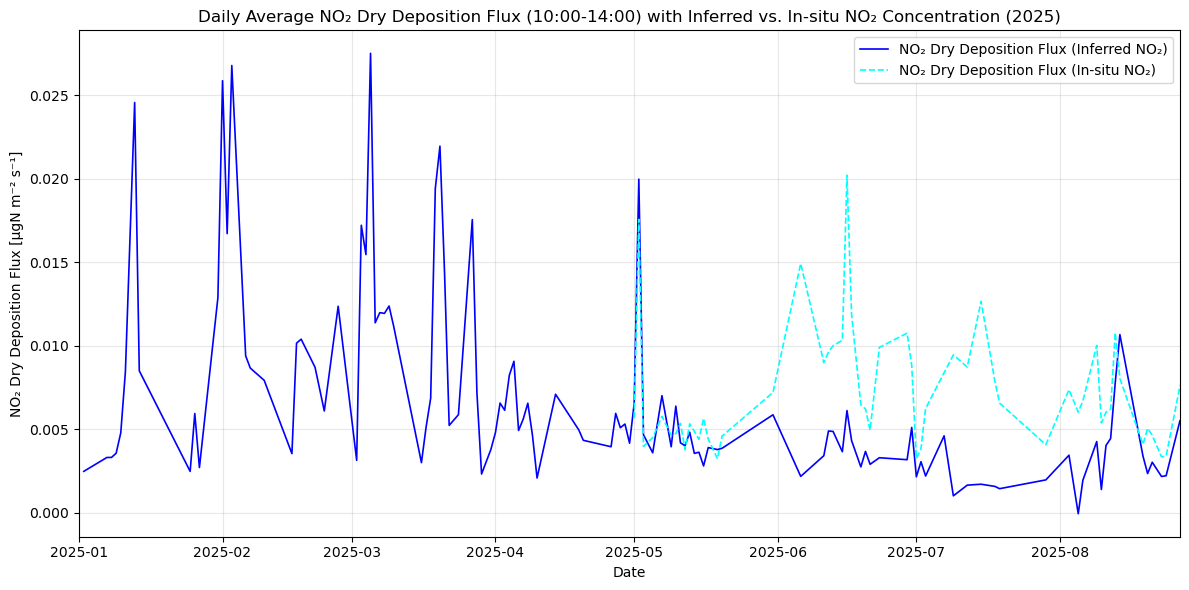

In [127]:
# plot it as a time-series
# the x-axis range is based on the range of last valid data of inferred no2
# Determine x-axis range based on last valid inferred NO2 data
last_valid_date = merged_vdno2_no2['Deposition_Flux_inferred'].dropna().index[-1]
last_valid_date = merged_vdno2_no2.loc[last_valid_date, 'Date']

# plot it as a time-series
plt.figure(figsize=(12, 6))
plt.plot(merged_vdno2_no2['Date'], merged_vdno2_no2['Deposition_Flux_inferred'].interpolate(), linestyle='-', color='blue', linewidth=1.2,
            label='NO₂ Dry Deposition Flux (Inferred NO₂)')
plt.plot(merged_vdno2_no2['Date'], merged_vdno2_no2['Deposition_Flux_insitu'].interpolate(), linestyle='--', color='cyan', linewidth=1.2,
            label='NO₂ Dry Deposition Flux (In-situ NO₂)')
plt.xlim(left=merged_vdno2_no2['Date'].min(), right=last_valid_date)
plt.title('Daily Average NO₂ Dry Deposition Flux (10:00-14:00) with Inferred vs. In-situ NO₂ Concentration (2025)')
plt.xlabel('Date')
plt.ylabel('NO₂ Dry Deposition Flux [µgN m⁻² s⁻¹]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [126]:
# Show the mean and maximum deposition fluxes for both inferred and in-situ NO2
mean_flux_inferred = merged_vdno2_no2['Deposition_Flux_inferred'].mean()
max_flux_inferred = merged_vdno2_no2['Deposition_Flux_inferred'].max()
mean_flux_insitu = merged_vdno2_no2['Deposition_Flux_insitu'].mean()
max_flux_insitu = merged_vdno2_no2['Deposition_Flux_insitu'].max()
print(f'Mean NO₂ Dry Deposition Flux (Inferred NO₂): {mean_flux_inferred:.4f} µgN m⁻² s⁻¹')
print(f'Max NO₂ Dry Deposition Flux (Inferred NO₂): {max_flux_inferred:.4f} µgN m⁻² s⁻¹')
print(f'Mean NO₂ Dry Deposition Flux (In-situ NO₂): {mean_flux_insitu:.4f} µgN m⁻² s⁻¹')
print(f'Max NO₂ Dry Deposition Flux (In-situ NO₂): {max_flux_insitu:.4f} µgN m⁻² s⁻¹')

Mean NO₂ Dry Deposition Flux (Inferred NO₂): 0.0066 µgN m⁻² s⁻¹
Max NO₂ Dry Deposition Flux (Inferred NO₂): 0.0275 µgN m⁻² s⁻¹
Mean NO₂ Dry Deposition Flux (In-situ NO₂): 0.0071 µgN m⁻² s⁻¹
Max NO₂ Dry Deposition Flux (In-situ NO₂): 0.0202 µgN m⁻² s⁻¹


In [86]:
# Read latent heat flux dataset
LE_data = pd.read_csv('../Data/VeluweInSitu/Loobos_LatentHeatFlux_2020_2025.csv', parse_dates=['Timestamp'])
# select only 2025 data
LE_data_2025 = LE_data[LE_data['Timestamp'].dt.year == 2025]
# select only the daytime period of 9 o'clock to 17 o'clock
LE_data_2025 = LE_data_2025[(LE_data_2025['Timestamp'].dt.hour >= 9) & (LE_data_2025['Timestamp'].dt.hour < 17)]
# calculate the daily average latent heat flux
LE_data_2025_daily = LE_data_2025.groupby(LE_data_2025['Timestamp'].dt.date)['LE'].mean().reset_index()
LE_data_2025_daily['Timestamp'] = pd.to_datetime(LE_data_2025_daily['Timestamp'])
# rename Timestamp to Date
LE_data_2025_daily.rename(columns={'Timestamp': 'Date'}, inplace=True)
print(LE_data_2025_daily.head())

        Date         LE
0 2025-01-01  12.103835
1 2025-01-02  23.067026
2 2025-01-03   9.118178
3 2025-01-04   1.613924
4 2025-01-05   2.733664


In [139]:
# print first lines of Loobos_meteo dataset
print(Loobos_meteo.head())

             Timestamp        H        L       LE  P_1_1_1   RH_1_1_1  \
0  2023-01-01 00:30:00 -28.6111  8561.43  64.4297      NaN  58.566778   
1  2023-01-01 01:00:00 -45.5390  3664.26  55.2674      NaN  58.634111   
2  2023-01-01 01:30:00 -23.2093  8399.95  65.6980      NaN  60.356222   
3  2023-01-01 02:00:00 -45.6610  4076.76  63.9316      NaN  60.026889   
4  2023-01-01 02:30:00 -16.7186  9879.25  58.2393      NaN  59.655111   

   SW_IN_1_1_1  SW_OUT_1_1_1   TA_1_1_1    WD_2_1_1  WS_2_1_1       u*  \
0    -4.587133     -3.092433  15.279111  225.966667  6.466778  1.40866   
1    -4.258978     -3.206900  15.314444  222.300000  6.960444  1.23955   
2    -6.914678     -2.860533  14.947778  222.111111  6.989778  1.30553   
3    -4.324711     -3.141467  14.767444  220.477778  6.904444  1.28562   
4    -4.296511     -3.140433  14.672889  221.411111  6.093000  1.23539   

              daytime       VPD  VdNO2 (cm s-1)  g_s (m s-1)  
0 2023-01-01 00:30:00  0.719377         0.00115     0

In [140]:
# select the column g_s (m s-1) from the Loobos_meteo dataset
g_s_data = Loobos_meteo[['daytime', 'g_s (m s-1)']]
# filter out only the daytime period of 9 o'clock to 17 o'clock
g_s_data_daytime = g_s_data[(g_s_data['daytime'].dt.hour >= 9) & (g_s_data['daytime'].dt.hour < 17)]
# calculate the daily average g_s
g_s_data_daytime_daily = g_s_data_daytime.groupby(g_s_data_daytime['daytime'].dt.date)['g_s (m s-1)'].mean().reset_index()
g_s_data_daytime_daily['daytime'] = pd.to_datetime(g_s_data_daytime_daily['daytime'])
# rename daytime to Date
g_s_data_daytime_daily.rename(columns={'daytime': 'Date'}, inplace=True)
print(g_s_data_daytime_daily.head())

        Date  g_s (m s-1)
0 2023-01-01     0.000605
1 2023-01-02     0.000418
2 2023-01-03     0.000309
3 2023-01-04     0.000258
4 2023-01-05     0.000574


        Date         LE  g_s (m s-1)
0 2025-01-01  12.103835     0.000091
1 2025-01-02  23.067026     0.001140
2 2025-01-03   9.118178     0.000463
3 2025-01-04   1.613924     0.000348
4 2025-01-05   2.733664     0.000133


Pearson r between Latent Heat Flux and Stomatal Conductance: 0.77
R² between Latent Heat Flux and Stomatal Conductance: 0.60


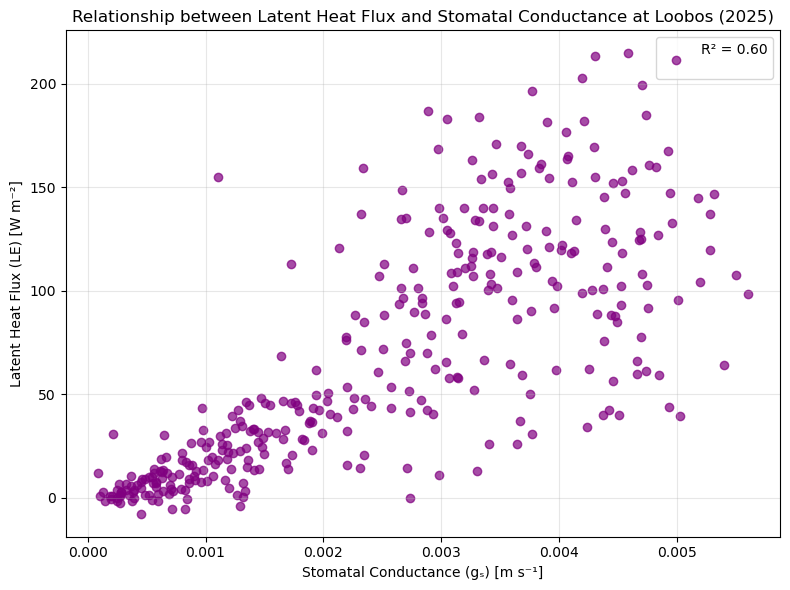

In [93]:
# Merge LE dataset with g_s dataset
from scipy import stats


merged_LE_gs = pd.merge(LE_data_2025_daily, g_s_data_daytime_daily, on='Date', how='inner')
print(merged_LE_gs.head())

# Calculate Pearson r and R²
r = merged_LE_gs['LE'].corr(merged_LE_gs['g_s (m s-1)'])
r_squared = r**2
print(f'Pearson r between Latent Heat Flux and Stomatal Conductance: {r:.2f}')
print(f'R² between Latent Heat Flux and Stomatal Conductance: {r_squared:.2f}')

# Calculate regression slope
slope, intercept, _, _, _ = stats.linregress(merged_LE_gs['g_s (m s-1)'], merged_LE_gs['LE'])

# Plot relationship
plt.figure(figsize=(8, 6))
plt.scatter(merged_LE_gs['g_s (m s-1)'], merged_LE_gs['LE'], color='purple', alpha=0.7,
            label=f'R² = {r_squared:.2f}\n')
plt.title('Relationship between Latent Heat Flux and Stomatal Conductance at Loobos (2025)')
plt.xlabel('Stomatal Conductance (gₛ) [m s⁻¹]')
plt.ylabel('Latent Heat Flux (LE) [W m⁻²]')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [130]:
# Load the vegetation indices dataset
# Vegetation indices csv, which contains columns of 'Date', 'NDVI', 'NDRE', 'CIred-edge', 'MTCI', 'MSAVI', 'NIRv', 'EVI'
VIs_data = pd.read_csv('../Data/Sentinel2/VegetationIndices_TimeSeries_New.csv', parse_dates=['Date'])
# Read another vegetation indices csv, select only the column of "CRswir" and "Date"
CRswir_data = pd.read_csv('../Data/Sentinel2/VegetationIndices_TimeSeries.csv', parse_dates=['Date'], usecols=['Date', 'CRSWIR'])
# Merge the CRswir data with the VIs_data on the 'Date' column to create a combined DataFrame
VIs_data = pd.merge(VIs_data, CRswir_data, on='Date', how='left')

In [142]:
# For VI data, only inlcude time after 2023
VIs_data = VIs_data[VIs_data['Date'].dt.year >= 2023]
# print and check the VIs_data
print(VIs_data.head())

          Date      NDVI      NIRv      WDVI     MSAVI       EVI      NDRE  \
136 2023-02-14  0.769431  0.146600  0.160636  0.308416  0.354486  0.552295   
137 2023-03-01  0.803423  0.152461  0.164913  0.318184  0.358094  0.577940   
138 2023-04-02  0.772292  0.153351  0.167934  0.321501  0.358703  0.544740   
139 2023-04-05  0.728013  0.139750  0.155666  0.297548  0.339600  0.519298   
141 2023-04-25  0.781257  0.163004  0.177863  0.339288  0.377431  0.542512   

      CIredge      MTCI    CRSWIR  NDVI_smooth  NDRE_smooth  CIredge_smooth  \
136  2.476160  3.142132  0.783170     0.784216     0.568042        2.651189   
137  2.749208  3.243151  0.764646     0.774708     0.556008        2.527495   
138  2.401081  2.992087  0.842782     0.770883     0.547357        2.435537   
139  2.168178  2.965340  0.925510     0.766141     0.541398        2.379420   
141  2.383059  2.790433  0.864089     0.742148     0.524523        2.220539   

     MTCI_smooth  MSAVI_smooth  NIRv_smooth  EVI_smooth 

In [141]:
# calculate monthly average of stomatal conductance (g_s) 
g_s_data_monthly = g_s_data.groupby(g_s_data['daytime'].dt.to_period('M'))['g_s (m s-1)'].mean().reset_index()
g_s_data_monthly['Date'] = g_s_data_monthly['daytime'].dt.to_timestamp()
g_s_data_monthly.drop(columns=['daytime'], inplace=True)
print(g_s_data_monthly.head())

   g_s (m s-1)       Date
0     0.000249 2023-01-01
1     0.000553 2023-02-01
2     0.000879 2023-03-01
3     0.001514 2023-04-01
4     0.001943 2023-05-01


In [143]:
# Create a function to calculate centered 5-point rolling mean to smooth the data, 
def smooth_vegetation_indices(df, index_col, date_col='Date', window=5):
    """
    Smooth the vegetation index using a centered rolling mean.
    Parameters:
    - df: DataFrame containing the vegetation index and date columns.
    - index_col: Name of the column containing the vegetation index to be smoothed.
    - date_col: Name of the column containing the date information (default is 'Date').
    - window: Size of the rolling window (default is 5).
    Returns:
    - DataFrame with an additional column for the smoothed vegetation index.
    The function first ensures that the date column is in datetime format, then drops any rows with missing values in the vegetation index column. 
    It calculates the centered rolling mean for the specified vegetation index and adds it as a new column to the DataFrame. The smoothed column 
    is named by appending '_smooth' to the original index column name.

    """
    # Ensure date column is datetime
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    # Drop missing values
    df = df.dropna(subset=[index_col])

    # Smooth the index
    smooth_col = f"{index_col}_smooth"
    df[smooth_col] = df[index_col].rolling(
        window=window, center=True, min_periods=1
    ).mean()
    return df
# Apply the smoothing function to each vegetation index
for index in ['NDVI', 'NDRE', 'CIredge', 'MTCI', 'MSAVI', 'NIRv', 'EVI', 'CRSWIR']:
    VIs_data = smooth_vegetation_indices(VIs_data, index)   
# print out the first few rows of the smoothed vegetation indices data to check
print(VIs_data.head())

          Date      NDVI      NIRv      WDVI     MSAVI       EVI      NDRE  \
136 2023-02-14  0.769431  0.146600  0.160636  0.308416  0.354486  0.552295   
137 2023-03-01  0.803423  0.152461  0.164913  0.318184  0.358094  0.577940   
138 2023-04-02  0.772292  0.153351  0.167934  0.321501  0.358703  0.544740   
139 2023-04-05  0.728013  0.139750  0.155666  0.297548  0.339600  0.519298   
141 2023-04-25  0.781257  0.163004  0.177863  0.339288  0.377431  0.542512   

      CIredge      MTCI    CRSWIR  NDVI_smooth  NDRE_smooth  CIredge_smooth  \
136  2.476160  3.142132  0.783170     0.781715     0.558325        2.542150   
137  2.749208  3.243151  0.764646     0.768289     0.548568        2.448657   
138  2.401081  2.992087  0.842782     0.770883     0.547357        2.435537   
139  2.168178  2.965340  0.925510     0.766141     0.541398        2.379420   
141  2.383059  2.790433  0.864089     0.742148     0.524523        2.220539   

     MTCI_smooth  MSAVI_smooth  NIRv_smooth  EVI_smooth 

In [144]:
# Ensure datetime format
VIs_data['Date'] = pd.to_datetime(VIs_data['Date'])
g_s_data_monthly['Date'] = pd.to_datetime(g_s_data_monthly['Date'])

# Create month column
VIs_data['Month'] = VIs_data['Date'].dt.to_period('M').dt.to_timestamp()

# List of vegetation indices
vis = ['NDVI', 'NDRE', 'CIredge', 'MTCI', 'MSAVI', 'NIRv', 'EVI', 'CRSWIR']

# Monthly averages using SMOOTHED columns
monthly_vi = (
    VIs_data
    .groupby('Month')[[f'{vi}_smooth' for vi in vis]]
    .mean()
    .reset_index()
    .rename(columns={'Month': 'Date'})
)

# Merge with gs dataframe
merged_data = pd.merge(
    monthly_vi,
    g_s_data_monthly[['Date', 'g_s (m s-1)']],
    on='Date',
    how='inner'
)

print(merged_data.head())

        Date  NDVI_smooth  NDRE_smooth  CIredge_smooth  MTCI_smooth  \
0 2023-02-01     0.781715     0.558325        2.542150     3.125790   
1 2023-03-01     0.768289     0.548568        2.448657     3.085677   
2 2023-04-01     0.751049     0.531975        2.292529     2.929197   
3 2023-05-01     0.702636     0.499059        2.004740     2.764638   
4 2023-06-01     0.691303     0.493570        1.960987     2.668112   

   MSAVI_smooth  NIRv_smooth  EVI_smooth  CRSWIR_smooth  g_s (m s-1)  
0      0.316034     0.150804    0.357094       0.796866     0.000553  
1      0.311412     0.148041    0.352721       0.829027     0.000879  
2      0.317447     0.150967    0.362435       0.875802     0.001514  
3      0.319794     0.151541    0.378592       0.910754     0.001943  
4      0.318743     0.150788    0.373046       0.893371     0.001878  


In [154]:
# rename column from " g_s (m s-1)" to "g_s"
merged_data = merged_data.rename(columns={'g_s (m s-1)': 'g_s'})

In [155]:
# print merged_data to check
print(merged_data.head())

        Date  NDVI_smooth  NDRE_smooth  CIredge_smooth  MTCI_smooth  \
0 2023-02-01     0.781715     0.558325        2.542150     3.125790   
1 2023-03-01     0.768289     0.548568        2.448657     3.085677   
2 2023-04-01     0.751049     0.531975        2.292529     2.929197   
3 2023-05-01     0.702636     0.499059        2.004740     2.764638   
4 2023-06-01     0.691303     0.493570        1.960987     2.668112   

   MSAVI_smooth  NIRv_smooth  EVI_smooth  CRSWIR_smooth       g_s  
0      0.316034     0.150804    0.357094       0.796866  0.000553  
1      0.311412     0.148041    0.352721       0.829027  0.000879  
2      0.317447     0.150967    0.362435       0.875802  0.001514  
3      0.319794     0.151541    0.378592       0.910754  0.001943  
4      0.318743     0.150788    0.373046       0.893371  0.001878  


In [163]:
from scipy.stats import linregress

def create_vi_gs_plot(data, vi, output_file):

    plot_data = data[[f'{vi}_smooth', 'g_s']].dropna()

    if len(plot_data) < 2:
        print(f"Skipping {vi}: insufficient data")
        return np.nan

    x = plot_data[f'{vi}_smooth']
    y = plot_data['g_s']

    # Linear regression
    slope, intercept, r, p, se = linregress(x, y)
    r2 = r**2

    fig, ax = plt.subplots(figsize=(6, 5))

    # Scatter
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = intercept + slope * x_fit

    ax.plot(
        x_fit,
        y_fit,
        linewidth=2,
        label=f'R² = {r2:.3f}\np = {p:.3f}'
    )

    ax.set_xlabel(f'{vi} (monthly mean smoothed)', fontsize=12)
    ax.set_ylabel(r'$g_s$ (m s$^{-1}$)', fontsize=12)
    ax.set_title(f'{vi} vs Stomatal Conductance', fontsize=14)

    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.close()

    return {
    'R2': r2,
    'r': r,
    'p': p,
    'slope': slope,
    'intercept': intercept
}

In [168]:
vis = ['NDVI', 'NDRE', 'CIredge', 'MTCI',
       'MSAVI', 'NIRv', 'EVI', 'CRSWIR']

results = {}

for vi in vis:
    stats = create_vi_gs_plot(
        merged_data,
        vi,
        os.path.join('../Output/RQ1', f'{vi}_vs_gs.png')
    )
    results[vi] = stats

print("\nRelationship between monthly smoothed VIs and g_s")
print("-" * 55)
print(f"{'VI':<10} {'R²':>8} {'r':>8} {'p-value':>12} {'slope':>10} {'intercept':>12}")
print("-" * 55)

for vi, stats in sorted(
        results.items(),
        key=lambda x: x[1]['R2'],
        reverse=True):

    print(
        f"{vi:<10} "
        f"{stats['R2']:>8.3f} "
        f"{stats['r']:>8.3f} "
        f"{stats['p']:>12.3e} "
        f"{stats['slope']:>10.3f} "
        f"{stats['intercept']:>12.3f}"
    )


Relationship between monthly smoothed VIs and g_s
-------------------------------------------------------
VI               R²        r      p-value      slope    intercept
-------------------------------------------------------
CRSWIR        0.644    0.803    1.925e-08      0.006       -0.003
NDVI          0.597   -0.773    1.352e-07     -0.014        0.012
CIredge       0.337   -0.581    3.974e-04     -0.001        0.004
NDRE          0.325   -0.570    5.301e-04     -0.010        0.007
MTCI          0.230   -0.479    4.754e-03     -0.001        0.004
EVI           0.003    0.058    7.469e-01      0.001        0.001
NIRv          0.002   -0.039    8.302e-01     -0.002        0.001
MSAVI         0.000   -0.004    9.846e-01     -0.000        0.001


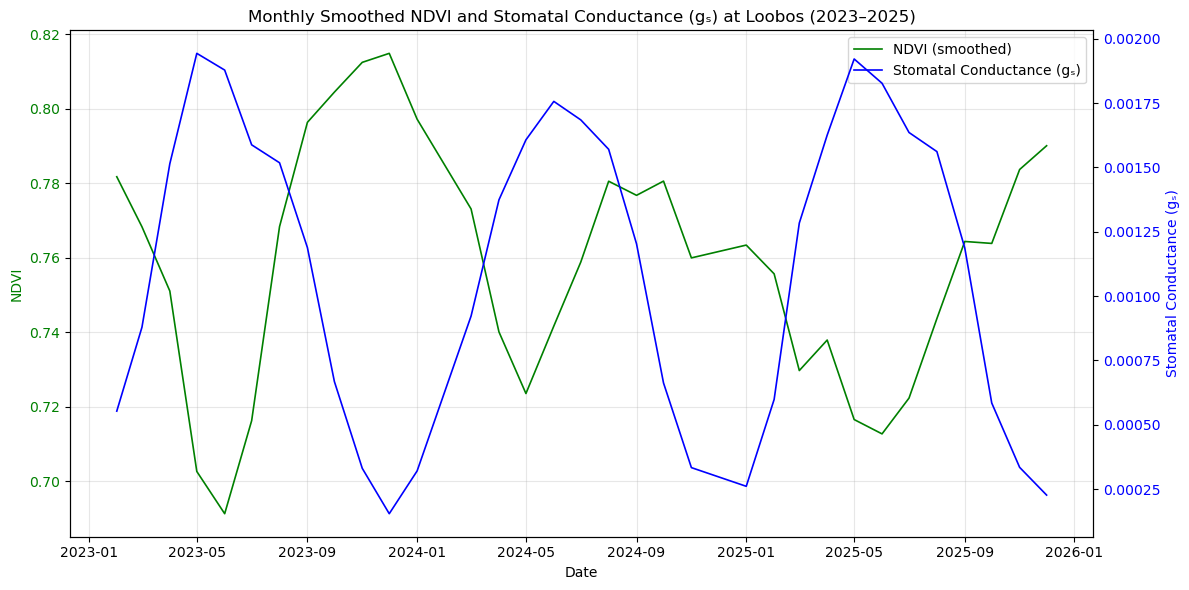

In [170]:
# plot time series between monthly smoothed NDVI and g_s with dual y-axes

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left y-axis (NDVI)
ax1.plot(merged_data['Date'], merged_data['NDVI_smooth'],
         color='green', linewidth=1.2, label='NDVI (smoothed)')
ax1.set_xlabel('Date')
ax1.set_ylabel('NDVI', color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.grid(alpha=0.3)

# Right y-axis (g_s)
ax2 = ax1.twinx()
ax2.plot(merged_data['Date'], merged_data['g_s'],
         color='blue', linewidth=1.2, label='Stomatal Conductance (gₛ)')
ax2.set_ylabel('Stomatal Conductance (gₛ)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Title
plt.title('Monthly Smoothed NDVI and Stomatal Conductance (gₛ) at Loobos (2023–2025)')

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

plt.tight_layout()
plt.savefig('../Output/RQ1/NDVI_vs_gs_timeseries.png', dpi=300)
plt.show()

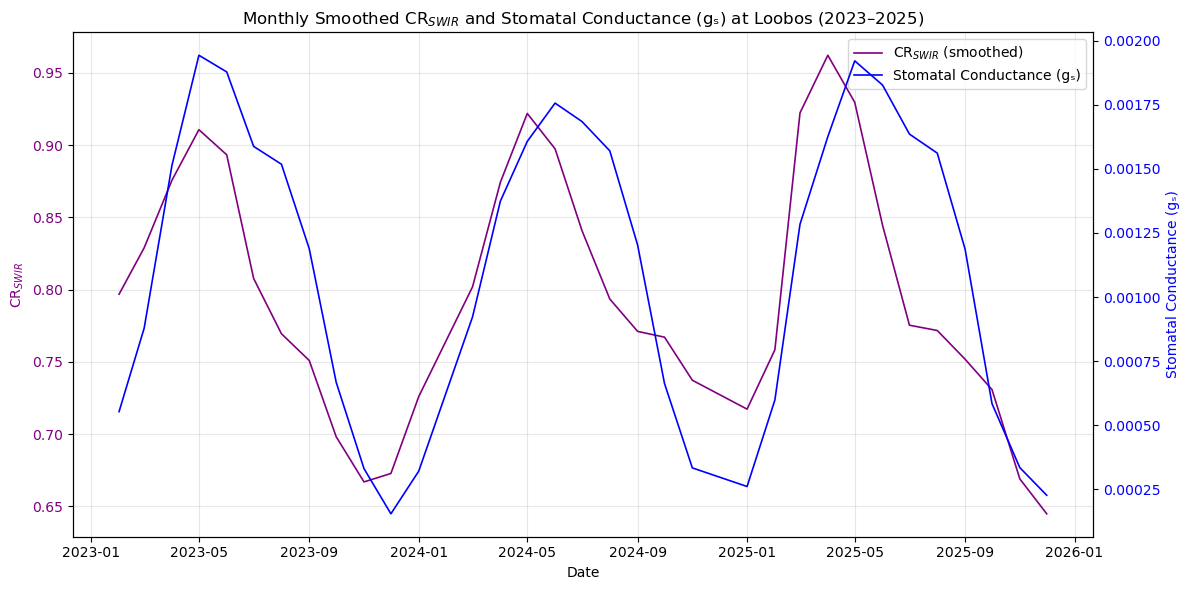

In [171]:
# plot time series between monthly smoothed CRSWIR and g_s with dual y-axes

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left y-axis (CRSWIR)
ax1.plot(merged_data['Date'], merged_data['CRSWIR_smooth'],
         color='purple', linewidth=1.2, label='CR$_{SWIR}$ (smoothed)')
ax1.set_xlabel('Date')
ax1.set_ylabel('CR$_{SWIR}$', color='purple')
ax1.tick_params(axis='y', labelcolor='purple')
ax1.grid(alpha=0.3)

# Right y-axis (g_s)
ax2 = ax1.twinx()
ax2.plot(merged_data['Date'], merged_data['g_s'],
         color='blue', linewidth=1.2, label='Stomatal Conductance (gₛ)')
ax2.set_ylabel('Stomatal Conductance (gₛ)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Title
plt.title('Monthly Smoothed CR$_{SWIR}$ and Stomatal Conductance (gₛ) at Loobos (2023–2025)')

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

plt.tight_layout()
plt.savefig('../Output/RQ1/CRSWIR_vs_gs_timeseries.png', dpi=300)
plt.show()